# Equity Research Portfolio — Interactive Walk-through

A mini institutional equity-research desk that both **analyzes** and **predicts** the same stocks:

1. **Data engine** — daily prices, volume, log returns (Yahoo Finance).
2. **Quantitative analysis** — returns, volatility, Sharpe, beta, correlation, rolling metrics.
3. **Visualization** — publication-quality charts.
4. **Research reports** — a structured note per company.
5. **Portfolio summary** — weighted returns, diversification, sector & correlation risk.
6. **Prediction** — walk-forward, out-of-sample next-day forecasts (with an honest baseline).

*Educational research project. Nothing here is investment advice.*

> Run order: `Kernel → Restart & Run All`. The first run downloads ~5y of daily
> data once; set `OFFLINE = True` below to reuse the cached CSVs in `data/processed`.

In [1]:
import os, sys
import numpy as np
import pandas as pd

# Make the `portfolio` package importable whether the notebook runs from the
# repo root or the notebooks/ folder.
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.isdir(os.path.join(ROOT, "portfolio")):
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from portfolio.src import config, data_engine, quant_analysis as qa
from portfolio.src import prediction, visualization as viz, report_generator, portfolio_summary

# Route requests through the pre-configured CA bundle if one is present.
_ca = "/root/.ccr/ca-bundle.crt"
if os.path.exists(_ca):
    os.environ.setdefault("REQUESTS_CA_BUNDLE", _ca)

OFFLINE = True   # True -> reuse cached data/processed CSVs; False -> download fresh
print("Universe:", ", ".join(config.TICKERS), "| Benchmark:", config.BENCHMARK)

Universe: AAPL, MSFT, NVDA, AMZN, TSLA, GOOGL, META, JPM | Benchmark: SPY


## Layer 1 — Data engine

Collect daily OHLCV + adjusted close, clean, align, and build master log-return matrix.

In [2]:
if OFFLINE and os.path.exists(os.path.join(config.PROCESSED_DIR, "master_log_returns.csv")):
    datasets = data_engine.load_processed()
else:
    datasets = data_engine.run()

adj_close   = datasets["adj_close"]
volume      = datasets["volume"]
log_returns = datasets["log_returns"]
print(f"{adj_close.shape[0]} trading days: {adj_close.index.min().date()} -> {adj_close.index.max().date()}")
adj_close.tail()

1254 trading days: 2021-08-06 -> 2026-08-05


,AAPL,MSFT,NVDA,AMZN,TSLA,GOOGL,META,JPM,SPY
date,,,,,,,,,
2026-07-30,333.429993,451.100006,195.039993,235.500000,308.850006,333.660004,539.030029,350.850006,741.690002
2026-07-31,308.910004,464.720001,200.750000,271.579987,311.209991,356.130005,556.710022,351.790009,747.030029
2026-08-03,303.420013,487.649994,206.639999,284.019989,322.079987,373.510010,590.239990,352.640015,757.669983
2026-08-04,309.380005,492.809998,211.940002,277.420013,327.350006,377.649994,587.940002,357.519989,771.330017
2026-08-05,311.000000,487.459991,219.220001,272.649994,321.549988,362.429993,588.770020,359.239990,769.789978


## Layer 2 — Quantitative analysis

Per-asset return, volatility, Sharpe, beta/alpha vs SPY, drawdown and tail-risk metrics.

In [3]:
analysis = qa.run(log_returns)
metrics  = analysis["metrics"]
metrics.style.format({
    "ann_return": "{:.1%}", "ann_volatility": "{:.1%}", "sharpe": "{:.2f}",
    "beta": "{:.2f}", "alpha_annual": "{:.1%}", "market_r2": "{:.2f}",
    "max_drawdown": "{:.1%}", "var_95_daily": "{:.2%}", "cvar_95_daily": "{:.2%}",
    "downside_dev": "{:.1%}", "corr_to_market": "{:.2f}",
})

Layer 2 | Quantitative analysis
  metrics_table: 9 assets x 11 metrics
  correlation_matrix: 8x8
  PCA: PC1 explains 53% of return variance
  rolling window: 60 days


,ann_return,ann_volatility,sharpe,beta,alpha_annual,market_r2,max_drawdown,var_95_daily,cvar_95_daily,downside_dev,corr_to_market
symbol,,,,,,,,,,,
AAPL,15.2%,28.0%,0.40,1.17,2.2%,0.52,-33.4%,-2.78%,-4.08%,19.4%,0.72
MSFT,10.5%,28.0%,0.23,1.12,-2.0%,0.48,-37.6%,-2.73%,-3.90%,19.2%,0.69
NVDA,47.8%,51.5%,0.85,2.12,24.2%,0.50,-66.4%,-4.96%,-6.94%,34.4%,0.71
AMZN,9.8%,36.3%,0.16,1.49,-6.7%,0.50,-55.7%,-3.39%,-5.15%,25.2%,0.71
TSLA,6.5%,59.6%,0.04,2.01,-15.9%,0.34,-73.6%,-5.93%,-8.58%,42.3%,0.58
GOOGL,19.8%,32.0%,0.49,1.25,5.9%,0.45,-44.3%,-3.10%,-4.53%,22.1%,0.67
META,9.7%,45.2%,0.13,1.58,-7.9%,0.36,-76.7%,-4.09%,-6.48%,32.9%,0.60
JPM,16.6%,24.5%,0.51,0.88,6.8%,0.38,-40.6%,-2.45%,-3.67%,17.2%,0.62
SPY,11.1%,17.2%,0.41,1.00,0.0%,1.00,-25.4%,-1.68%,-2.50%,12.1%,1.00


### Correlation matrix

In [4]:
analysis['correlation'].style.format('{:.2f}').background_gradient(cmap='coolwarm', vmin=0, vmax=1)

,AAPL,MSFT,NVDA,AMZN,TSLA,GOOGL,META,JPM
AAPL,1.00,0.53,0.48,0.50,0.46,0.52,0.44,0.36
MSFT,0.53,1.00,0.57,0.61,0.38,0.55,0.51,0.30
NVDA,0.48,0.57,1.00,0.54,0.47,0.50,0.48,0.33
AMZN,0.50,0.61,0.54,1.00,0.44,0.62,0.59,0.35
TSLA,0.46,0.38,0.47,0.44,1.00,0.42,0.35,0.32
GOOGL,0.52,0.55,0.50,0.62,0.42,1.00,0.53,0.32
META,0.44,0.51,0.48,0.59,0.35,0.53,1.00,0.29
JPM,0.36,0.30,0.33,0.35,0.32,0.32,0.29,1.00


## Layer 6 — Prediction (walk-forward, out-of-sample)

Can we forecast next-day *direction* for each stock better than a coin flip and
better than a random walk? The models are trained only on prior data (no
look-ahead), and directional accuracy is the honest metric.

In [5]:
pred = prediction.run(log_returns)
pred["metrics"].pivot(index="model", columns="symbol", values="directional_accuracy").mul(100).round(1)

Layer 6 | Prediction (walk-forward, out-of-sample)


  AAPL: best RandomForest 52.2% directional accuracy (989 test days)


  MSFT: best RandomForest 51.5% directional accuracy (991 test days)


  NVDA: best RidgeReturn 53.5% directional accuracy (990 test days)


  AMZN: best RidgeReturn 50.2% directional accuracy (988 test days)


  TSLA: best RandomWalk 51.0% directional accuracy (990 test days)


  GOOGL: best RandomForest 52.1% directional accuracy (989 test days)


  META: best RidgeReturn 50.3% directional accuracy (989 test days)


  JPM: best RandomForest 53.6% directional accuracy (990 test days)
  mean directional accuracy by model:
    RidgeReturn  50.5%
    RandomWalk   50.5%
    RandomForest 50.5%
    LogisticDir  50.3%
  wrote reports/PREDICTION_REPORT.md


symbol,AAPL,AMZN,GOOGL,JPM,META,MSFT,NVDA,TSLA
model,,,,,,,,
LogisticDir,51.3,47.9,50.9,52.0,50.1,51.1,53.2,46.4
RandomForest,52.2,48.4,52.1,53.6,48.8,51.5,51.9,45.6
RandomWalk,51.0,49.3,50.6,51.1,49.7,50.6,50.9,51.0
RidgeReturn,49.9,50.2,51.0,49.9,50.3,50.2,53.5,49.3


## Layer 3 — Visualization

Regenerate the full chart deck (including the two prediction charts) and display a few inline.

In [6]:
viz.apply_style()
paths = viz.run(datasets, analysis, pred_metrics=pred["metrics"])
print("Charts written to:", os.path.relpath(config.CHARTS_DIR, ROOT))
[os.path.basename(p) for p in paths]

Layer 3 | Visualization


  saved charts/01_normalized_prices.png
  saved charts/02_return_comparison.png
  saved charts/03_correlation_heatmap.png
  saved charts/04_rolling_volatility.png
  saved charts/05_risk_return_scatter.png
  saved charts/06_portfolio_allocation.png
  saved charts/07_drawdowns.png
  saved charts/08_rolling_corr_market.png
  saved charts/09_prediction_accuracy.png
  saved charts/10_prediction_vs_coinflip.png
Charts written to: portfolio/charts


['01_normalized_prices.png',
 '02_return_comparison.png',
 '03_correlation_heatmap.png',
 '04_rolling_volatility.png',
 '05_risk_return_scatter.png',
 '06_portfolio_allocation.png',
 '07_drawdowns.png',
 '08_rolling_corr_market.png',
 '09_prediction_accuracy.png',
 '10_prediction_vs_coinflip.png']

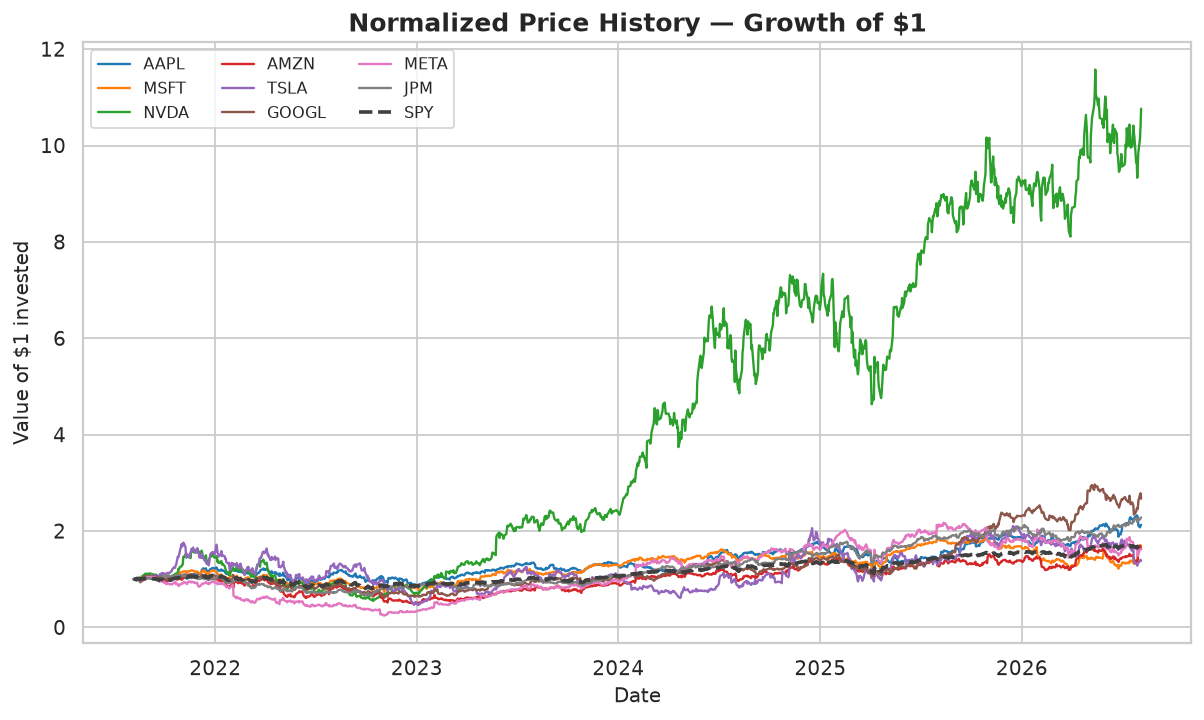

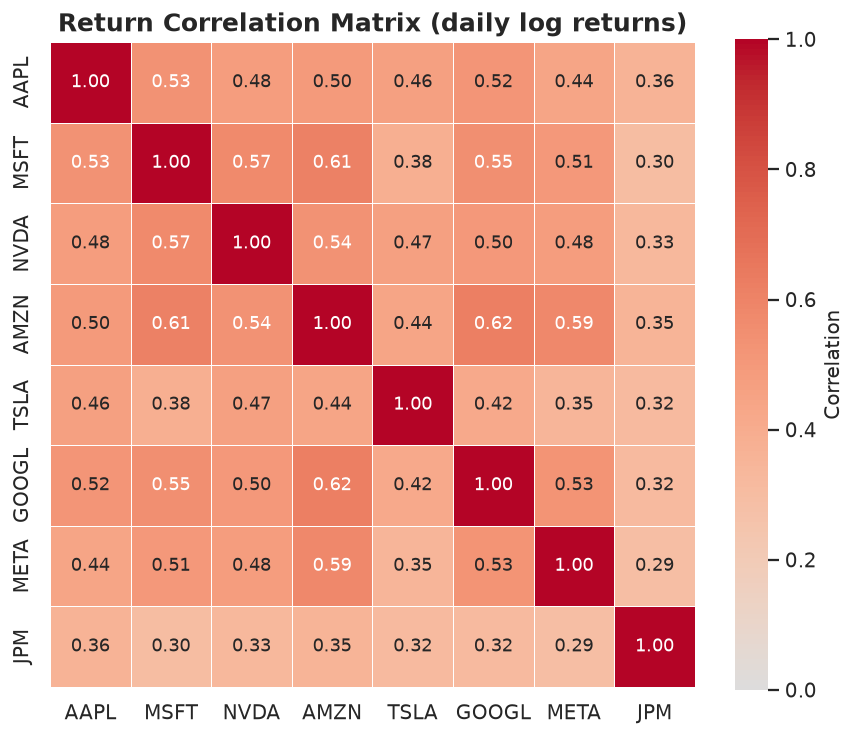

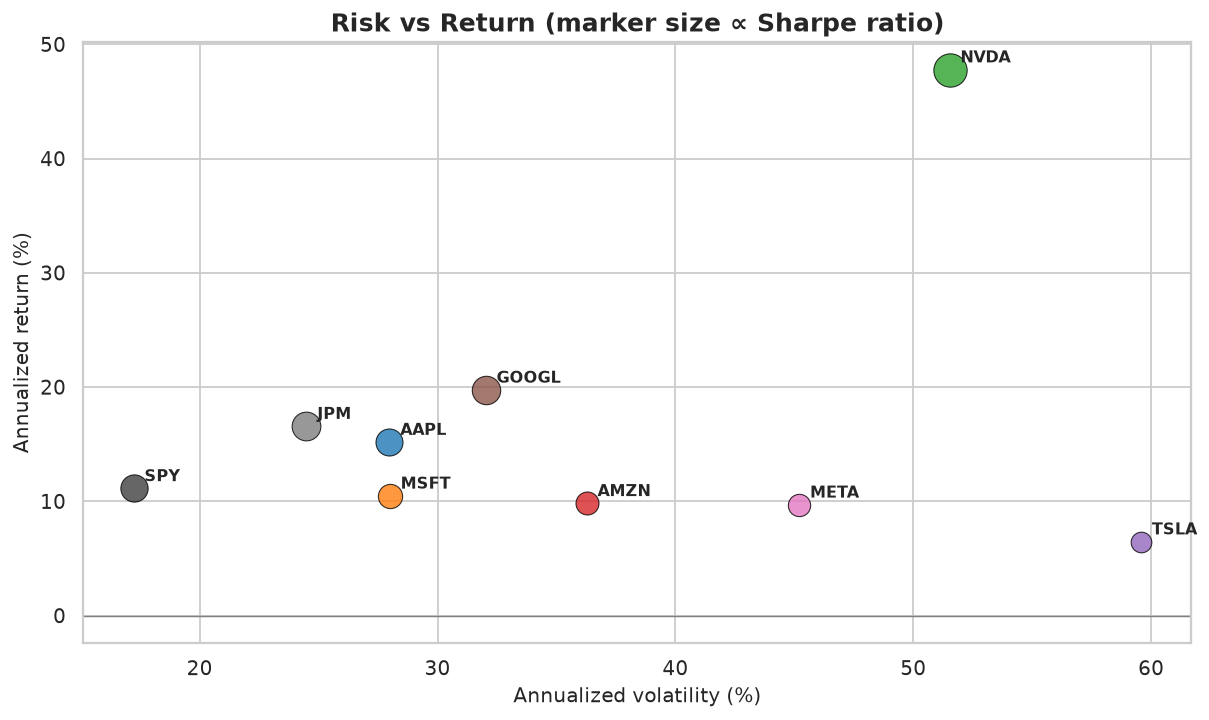

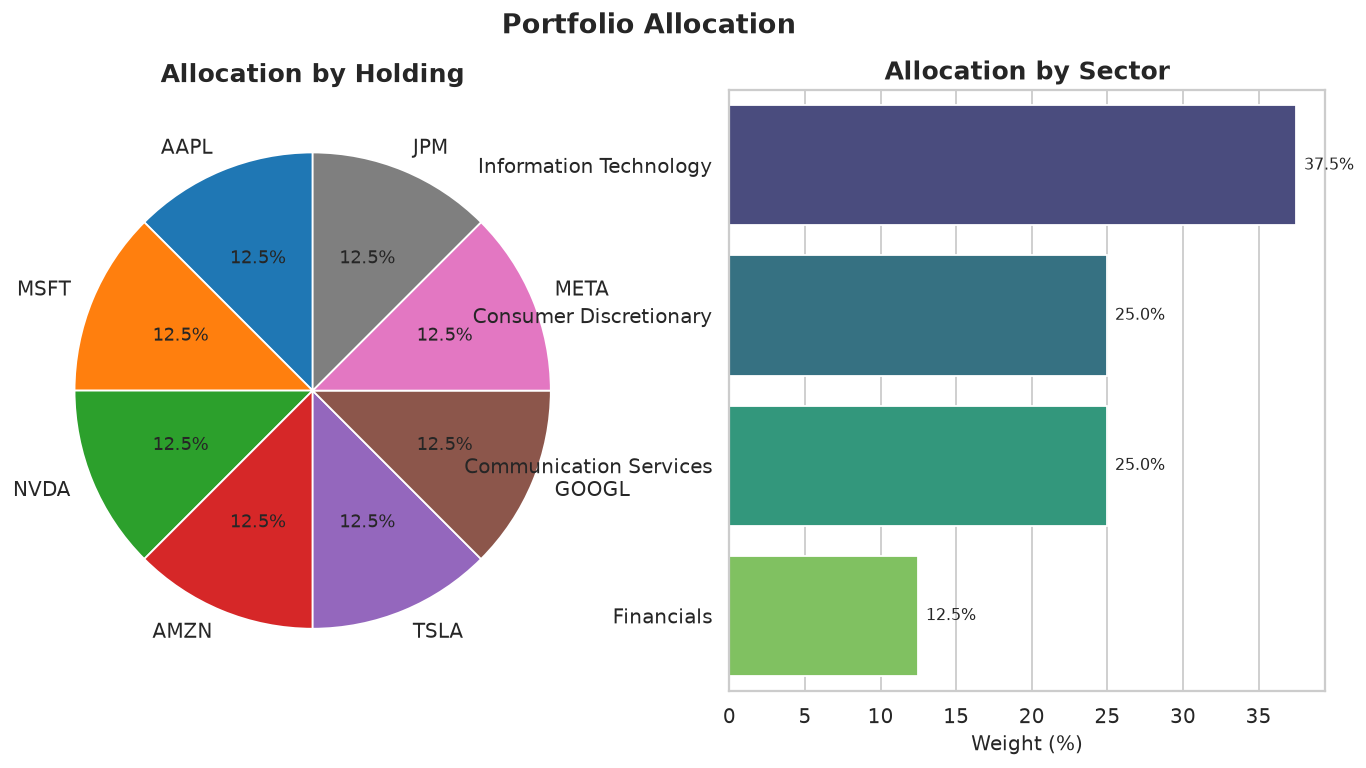

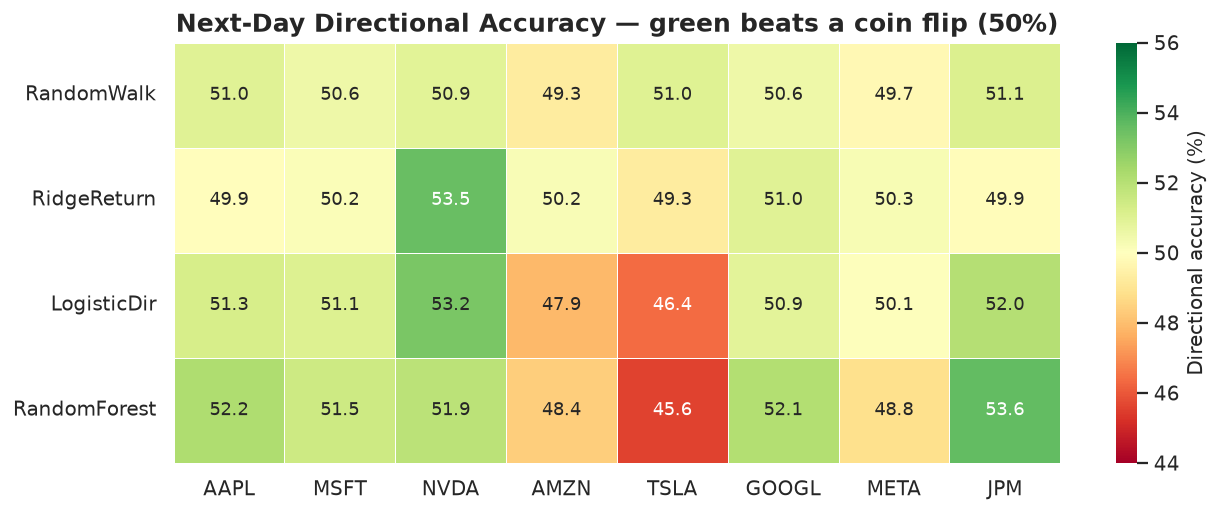

In [7]:
from IPython.display import Image, display
for name in ["01_normalized_prices.png", "03_correlation_heatmap.png",
            "05_risk_return_scatter.png", "06_portfolio_allocation.png",
            "09_prediction_accuracy.png"]:
    display(Image(filename=os.path.join(config.CHARTS_DIR, name)))

## Layer 4 — Research reports

Generate a structured Markdown note per holding (overview, quant, risk, thesis).

In [8]:
report_paths = report_generator.run(analysis)
from IPython.display import Markdown
# Preview the highest-Sharpe name's note.
top = metrics.drop(index=config.BENCHMARK)["sharpe"].idxmax()
Markdown(open(os.path.join(config.REPORTS_DIR, f"{top}_report.md")).read())

Layer 4 | Stock research reports
  AAPL: reports/AAPL_report.md
  MSFT: reports/MSFT_report.md
  NVDA: reports/NVDA_report.md
  AMZN: reports/AMZN_report.md
  TSLA: reports/TSLA_report.md
  GOOGL: reports/GOOGL_report.md
  META: reports/META_report.md
  JPM: reports/JPM_report.md
  index: reports/INDEX.md


# NVIDIA Corporation (NVDA) — Equity Research Note

**Sector:** Information Technology  |  **Industry:** Semiconductors
*Educational research project. Not investment advice.*

---

## A. Company overview

**Business model.** Designs GPUs and accelerated-computing platforms for data centers, gaming, professional visualization, and automotive, paired with the CUDA software ecosystem.

**Industry position.** The dominant supplier of AI training and inference accelerators, with a software moat (CUDA) that raises switching costs well beyond the silicon itself.

---

## B. Quantitative performance
*Trailing 5y of daily log returns, annualized (252 trading days).*

| Metric | NVDA | SPY | Read |
|---|---|---|---|
| Annualized return | 47.8% | 11.1% | Ahead of the market |
| Annualized volatility | 51.5% | 17.2% | More volatile |
| Sharpe ratio | 0.85 | 0.41 | Risk-adjusted return |
| Beta vs SPY | 2.12 | 1.00 | Market sensitivity |
| Annualized alpha | +24.2% | — | Return beyond beta |
| Correlation to market | 0.71 | 1.00 | Co-movement |

---

## C. Risk analysis

- **Downside / drawdown.** Worst peak-to-trough decline over the window was
  **-66.4%**. Annualized downside deviation
  (volatility of losing days only) is 34.4%.
- **Tail risk.** One-day 95% Value-at-Risk is -4.96%
  and Conditional VaR (average loss in the worst 5% of days) is
  -6.94%.
- **Market sensitivity.** With a beta of 2.12, the stock is highly sensitive to broad market moves; the market explains 50% of its return variance (R²), leaving 50% idiosyncratic.
- **Sector exposure.** Concentrated in **Information Technology**; the position
  inherits that sector's macro drivers and moves with its peers.

---

## D. Investment thesis

**Bullish arguments**
- Outperformed the market on an absolute basis (47.8% vs 11.1% annualized).
- Positive annualized alpha (+24.2%) — return beyond what its market beta explains.
- High beta (2.12) offers leveraged upside in market rallies.

**Bearish arguments**
- Volatility (51.5%) runs well above the market (17.2%) — a rough ride.
- Deep peak-to-trough drawdown (-66.4%) shows how far it can fall.
- Very high beta (2.12) amplifies losses in market sell-offs.
- High correlation to the market (0.71) limits its diversification value in a book.

**Recommendation (rules-based): `HOLD`**

Risk-adjusted return is fair (Sharpe 0.85). This tilt is generated mechanically from the trailing risk-adjusted
return and is *not* a substitute for fundamental valuation work or investment
advice.

---
*Generated by the equity research portfolio system. Educational use only.*


## Layer 5 — Portfolio summary

Weighted return & volatility (from the covariance matrix), diversification ratio, sector & correlation risk.

In [9]:
summary = portfolio_summary.run(datasets, analysis)
stats = summary["stats"]
print(f"Portfolio: return {stats['ann_return']:.1%} | vol {stats['ann_volatility']:.1%} | "
    f"Sharpe {stats['sharpe']:.2f} | beta {stats['beta']:.2f} | "
    f"diversification ratio {stats['diversification_ratio']:.2f}")
Markdown(open(os.path.join(config.REPORTS_DIR, "PORTFOLIO_SUMMARY.md")).read())

Layer 5 | Portfolio summary
  portfolio ann.return 17.0%  vol 27.8%  sharpe 0.47  beta 1.45
  wrote reports/PORTFOLIO_SUMMARY.md
Portfolio: return 17.0% | vol 27.8% | Sharpe 0.47 | beta 1.45 | diversification ratio 1.37


# Portfolio Summary — Model Equity Book

*Educational research project. Not investment advice.*

Equal-weight book of 8 large-cap holdings, benchmarked to SPY.
Statistics are computed from 5y of daily log returns and are
annualized with the square-root-of-time rule (252 trading days).

## 1. Headline metrics

| Metric | Portfolio | SPY (benchmark) |
|---|---|---|
| Annualized return | **17.0%** | 11.1% |
| Annualized volatility | **27.8%** | 17.2% |
| Sharpe ratio (rf=4%) | **0.47** | 0.41 |
| Beta vs SPY | 1.45 | 1.00 |
| Annualized alpha | 0.8% | — |
| Max drawdown | -48.7% | -25.4% |
| 1-day 95% VaR | -2.91% | — |
| 1-day 95% CVaR | -4.04% | — |

The book returned **+5.8%** annualized above
the benchmark, at a beta of 1.45.

## 2. Holdings

| Ticker | Company | Sector | Weight | Ann. Return | Ann. Vol | Sharpe | Beta |
|---|---|---|---|---|---|---|---|
| AAPL | Apple Inc. | Information Technology | 12.5% | 15.2% | 28.0% | 0.40 | 1.17 |
| MSFT | Microsoft Corporation | Information Technology | 12.5% | 10.5% | 28.0% | 0.23 | 1.12 |
| NVDA | NVIDIA Corporation | Information Technology | 12.5% | 47.8% | 51.5% | 0.85 | 2.12 |
| AMZN | Amazon.com, Inc. | Consumer Discretionary | 12.5% | 9.8% | 36.3% | 0.16 | 1.49 |
| TSLA | Tesla, Inc. | Consumer Discretionary | 12.5% | 6.5% | 59.6% | 0.04 | 2.01 |
| GOOGL | Alphabet Inc. | Communication Services | 12.5% | 19.8% | 32.0% | 0.49 | 1.25 |
| META | Meta Platforms, Inc. | Communication Services | 12.5% | 9.7% | 45.2% | 0.13 | 1.58 |
| JPM | JPMorgan Chase & Co. | Financials | 12.5% | 16.6% | 24.5% | 0.51 | 0.88 |

## 3. Diversification analysis

| Measure | Value | Reading |
|---|---|---|
| Weighted-avg standalone volatility | 38.1% | Risk if holdings moved in lockstep |
| Realized portfolio volatility | 27.8% | Actual, after diversification |
| **Diversification ratio** | **1.37** | >1 means diversification is working |
| Average pairwise correlation | 0.46 | Lower is better diversified |
| Herfindahl index (HHI) | 0.125 | Concentration (1/N = 0.125 if perfectly equal) |
| Effective number of holdings | 8.0 | vs 8 nominal names |

Diversification lowered realized volatility from a weighted-average
38.1% to 27.8%
(a diversification ratio of 1.37).

## 4. Sector exposure

| Sector | Weight |
|---|---|
| Information Technology | 37.5% |
| Consumer Discretionary | 25.0% |
| Communication Services | 25.0% |
| Financials | 12.5% |

The book is technology-tilted; sector concentration is the primary
non-diversifiable exposure and should be read alongside the correlation note below.

## 5. Correlation risk

Average pairwise correlation among the holdings is **0.46**.

Moderate average pairwise correlation. Some diversification, but the holdings still tend to move together in risk-off episodes.

A principal-component analysis of the holdings' returns confirms this: the first principal component — a common market/technology factor — alone explains **53%** of the cross-sectional return variance. That is the systematic core of the book's risk, which holding these particular names together cannot diversify away.

The correlation matrix (see `charts/03_correlation_heatmap.png`) shows the
technology and communication-services names clustering tightly, while SPY
-relative diversification comes mainly from JPM (Financials), whose return drivers
(rates, credit) differ from the secular-growth names.

## 6. Takeaways

- The portfolio earns its return by taking **above-market beta**
  (1.45) and a technology growth tilt.
- Diversification is **moderate**:
  the names share a common growth/rates factor, so drawdowns cluster.
- The clearest diversifier in the current set is the Financials sleeve (JPM);
  adding uncorrelated exposures (e.g. defensives, energy, international) would
  raise the diversification ratio further.

---
*Generated by the equity research portfolio system. Educational use only — not investment advice.*


## Recap

Everything above is fully reproducible from `portfolio/src`:

```bash
python -m portfolio.src.main            # download + full pipeline
python -m portfolio.src.main --offline  # reuse cached data
```

*Educational research project. Not investment advice.*